# Risky Debt Model: Adaptive Nested VFI with z-Interpolation

Two-stage adaptive solver benchmark:
1. **Coarse stage**: fast solve on a small grid with full b' range to discover the economically active region (where default risk is non-trivial).
2. **Fine stage**: production solve with tight b' bounds on the discovered region, using z-interpolation for speedup.

Uses the same environment and economic parameters as `03_risky_debt_benchmark.ipynb`.

In [1]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
from pathlib import Path

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _REPO_ROOT = Path(_nb_file).parent.parent
else:
    _REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from src.v2.evaluation import prepare_evaluation_run, save_figure, save_manifest_sections, save_solver_bundle
from src.v2.environments.risky_debt import EconomicParams, RiskyDebtEnv, ShockParams
from src.v2.solvers import RiskyDebtSolverConfig, solve_risky_debt

print(f"TF version: {tf.__version__}")

/Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TF version: 2.16.2


In [2]:
EXPERIMENT_NAME = "risky_debt_interp_vfi"

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _repo_root = Path(_nb_file).parent.parent
else:
    _repo_root = Path.cwd().parent

RUN = prepare_evaluation_run(
    experiment_name=EXPERIMENT_NAME,
    save_run=True,
    results_root=str(_repo_root / "outputs" / "notebooks"),
    run_tag="part1-interp-benchmark"
)
print(f"Run dir: {RUN['run_dir']}")

PROFILE = "FULL"
_PROFILES = {
    "FAST_DEBUG": dict(n_k=20, n_b=100, n_z=15, n_z_solve=7),
    "FULL":       dict(n_k=30, n_b=150, n_z=30, n_z_solve=10),
}

# Adaptive b' bounds: set adaptive=False to use full b' range
ADAPTIVE = True
BUFFER_FRAC = 0.15

env = RiskyDebtEnv(
    econ_params=EconomicParams(
        interest_rate=0.05,
        depreciation_rate=0.15,
        production_elasticity=0.7,
        cost_convex=0.01,
        tax=0.3,
        default_haircut=0.5,
        cost_inject_fixed=0.1,
        cost_inject_linear=0.05,
    ),
    shock_params=ShockParams(mu=0.0, rho=0.7, sigma=0.15),
    k_min_mult=0.05,
    k_max_mult=1.5,
    b_max_mult=4.0,
    b_min_mult=0.2,
)

config = RiskyDebtSolverConfig(
    **_PROFILES[PROFILE],
    adaptive=ADAPTIVE,
    buffer_frac=BUFFER_FRAC,
)

save_manifest_sections(
    RUN,
    profile=PROFILE,
    solver="solve_risky_debt",
    solver_config={
        "n_k": config.n_k,
        "n_b": config.n_b,
        "n_z": config.n_z,
        "n_z_solve": config.n_z_solve,
        "adaptive": config.adaptive,
        "buffer_frac": config.buffer_frac,
    },
)

print(f"Profile: {PROFILE}")
print(f"State bounds: k in [{env.k_min:.2f}, {env.k_max:.2f}], b in [{env.b_min:.2f}, {env.b_max:.2f}], z in [{env.z_min:.3f}, {env.z_max:.3f}]")
print(f"Grid: k={config.n_k} x b={config.n_b} x z={config.n_z} (z_solve={config.n_z_solve})")
print(f"Adaptive: {config.adaptive} (buffer={config.buffer_frac:.0%})")

Run dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/risky_debt_interp_vfi/part1-interp-benchmark
Profile: FULL
State bounds: k in [1.03, 30.87], b in [-24.70, 123.50], z in [0.533, 1.878]
Grid: k=30 x b=150 x z=30 (z_solve=10)
Adaptive: True (buffer=15%)


In [3]:
t0 = time.perf_counter()
result = solve_risky_debt(env, config=config)
wall_time = time.perf_counter() - t0

save_solver_bundle(
    RUN,
    result,
    summary={
        "solver": "solve_risky_debt",
        "backend": result["backend"],
        "dtype": result["dtype"],
        "device": result["device"],
        "stop_reason": result["stop_reason"],
        "converged_outer": result["converged_outer"],
        "n_outer": result["n_outer"],
        "n_inner_last": result["n_inner_last"],
        "n_z_solve": result["n_z_solve"],
        "n_z": result["n_z"],
        "adaptive_b_bounds": result.get("adaptive_b_bounds"),
        "wall_time_sec": wall_time,
    },
    name="solve_risky_debt",
)

grids = result["grids"]
z_grid = np.asarray(grids["exo_grids_1d"][0])
k_grid = np.asarray(grids["endo_grids_1d"][0])
b_grid = np.asarray(grids["endo_grids_1d"][1])
n_z, n_k, n_b = len(z_grid), len(k_grid), len(b_grid)

value_3d = np.asarray(result["value"]).reshape(n_z, n_k, n_b)
policy_endo_4d = np.asarray(result["policy_endo"]).reshape(n_z, n_k, n_b, 2)
default_mask = np.asarray(result["default_mask"])
r_tilde_grid = np.asarray(result["r_tilde_grid"])
residual = np.asarray(result["zero_profit_residual"])
funded_mask = np.asarray(result["funded_mask"])
solvent_mask = ~default_mask
policy_b_solvent = policy_endo_4d[..., 1][solvent_mask]
min_policy_b_solvent = np.min(policy_b_solvent) if policy_b_solvent.size else np.nan

outer_value_diff_final = result["outer_value_diff_history"][-1] if result["outer_value_diff_history"] else np.nan
pricing_diff_final = result["pricing_diff_history"][-1] if result["pricing_diff_history"] else np.nan
max_residual = np.nanmax(np.abs(residual[funded_mask])) if funded_mask.any() else np.nan

print(f"Backend: {result['backend']} | dtype={result['dtype']} | device={result['device']}")
if "adaptive_b_bounds" in result:
    b_lo, b_hi = result["adaptive_b_bounds"]
    print(f"Adaptive b' bounds: [{b_lo:.1f}, {b_hi:.1f}] (from full [{env.b_min:.1f}, {env.b_max:.1f}])")
    print(f"Coarse stage: {result.get('coarse_wall_sec', 0):.1f}s")
print(f"Stop reason: {result['stop_reason']} | wall={wall_time:.2f}s")
print(f"z-interp: {result['n_z_solve']} solve / {result['n_z']} fine nodes")
print(f"Outer iterations: {result['n_outer']} | inner last: {result['n_inner_last']}")
print(f"Final outer value diff: {outer_value_diff_final:.2f}")
print(f"Final pricing diff: {pricing_diff_final:.2f}")
print(f"Value range: [{value_3d.min():.3f}, {value_3d.max():.3f}]")
print(f"Default fraction: {default_mask.mean():.2%}")
print(f"Infinite-rate fraction: {np.isinf(r_tilde_grid).mean():.2%}")
print(f"Max |zero-profit residual| on funded cells: {max_residual:.3e}")
print(f"Min chosen b' on solvent states: {min_policy_b_solvent:.3f}")

solve_risky_debt: boundary discovery (15x15x15) ...
  outer=  0 | inner=converged (275 iters, diff=9.58e-07) | outer_value_diff=17.92 | pricing_diff=0.86
  outer=  1 | inner=converged (236 iters, diff=9.60e-07) | outer_value_diff=3.07 | pricing_diff=0.95
  outer=  2 | inner=converged (173 iters, diff=9.57e-07) | outer_value_diff=0.40 | pricing_diff=0.60
  outer=  3 | inner=converged (1 iters, diff=9.10e-07) | outer_value_diff=0.00 | pricing_diff=0.58
solve_risky_debt: active b' in [53.6, 108.7] (discovered in 0.3s)
solve_risky_debt: fine solve (30x150x30, z_solve=10) ...
  outer=  0 | inner=converged (282 iters, diff=9.56e-07) | outer_value_diff=28.78 | pricing_diff=0.86
  outer=  1 | inner=converged (249 iters, diff=9.93e-07) | outer_value_diff=4.47 | pricing_diff=0.95
  outer=  2 | inner=converged (224 iters, diff=9.94e-07) | outer_value_diff=1.28 | pricing_diff=0.89
  outer=  3 | inner=converged (198 iters, diff=9.87e-07) | outer_value_diff=0.46 | pricing_diff=0.57
  outer=  4 | inn

In [4]:
VALUE_TOL = 1e-8
z_bar = float(np.exp(env.shocks.mu))
z_ref_idx = int(np.argmin(np.abs(z_grid - z_bar)))
z_ref = float(z_grid[z_ref_idx])

# Column 1 (vs z) and Column 2 (vs k): median k, low b
k_ref_idx = 3 * n_k // 4
b_ref_idx = n_b // 25
k_ref = float(k_grid[k_ref_idx])
b_ref = float(b_grid[b_ref_idx])

# Column 3 (vs b): high k so firm is solvent across most b range
k_bslice_idx = 99 * n_k // 100
k_bslice = float(k_grid[k_bslice_idx])

print(f"Ref (z,k slices): z={z_ref:.2f}, k={k_ref:.2f}, b={b_ref:.1f}")
print(f"Ref (b slice):    z={z_ref:.2f}, k={k_bslice:.2f}")

# Slices for columns 1-2
value_z = value_3d[:, k_ref_idx, b_ref_idx]
value_k = value_3d[z_ref_idx, :, b_ref_idx]
policy_z = policy_endo_4d[:, k_ref_idx, b_ref_idx, :]
policy_k = policy_endo_4d[z_ref_idx, :, b_ref_idx, :]

# Slices for column 3 (high k)
value_b = value_3d[z_ref_idx, k_bslice_idx, :]
policy_b = policy_endo_4d[z_ref_idx, k_bslice_idx, :, :]

def _mask_default(policy, value):
    return np.where(value[:, None] > VALUE_TOL, policy, np.nan)

policy_z_plot = _mask_default(policy_z, value_z)
policy_k_plot = _mask_default(policy_k, value_k)
policy_b_plot = _mask_default(policy_b, value_b)

Ref (z,k slices): z=0.98, k=13.58, b=55.8
Ref (b slice):    z=0.98, k=30.87


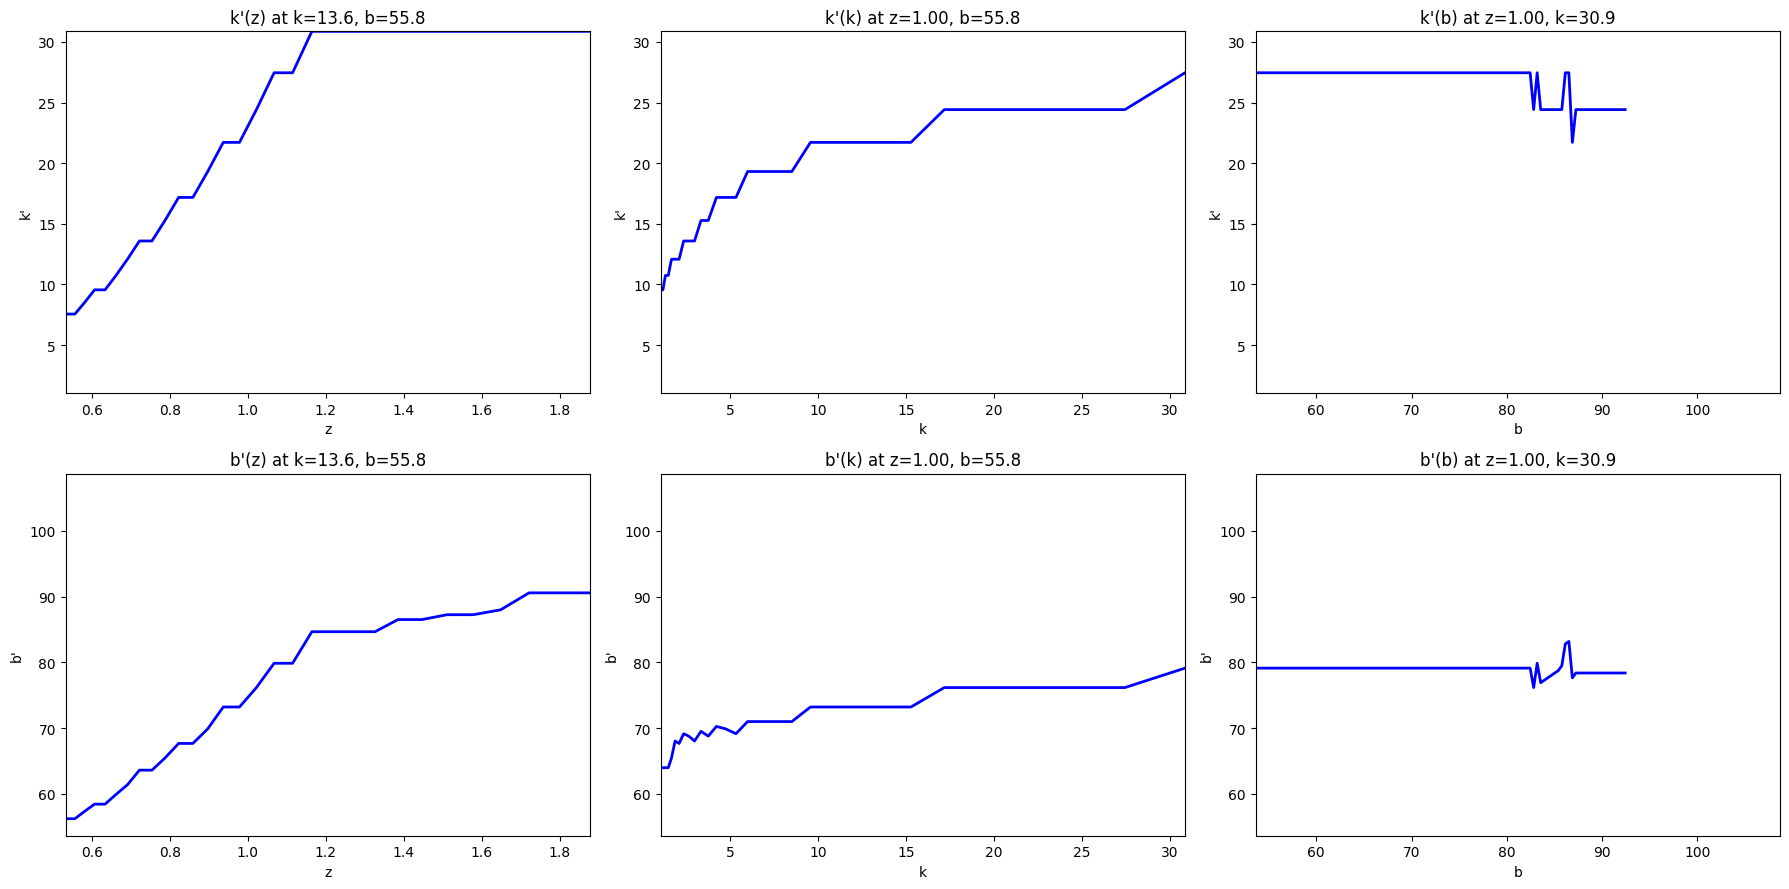

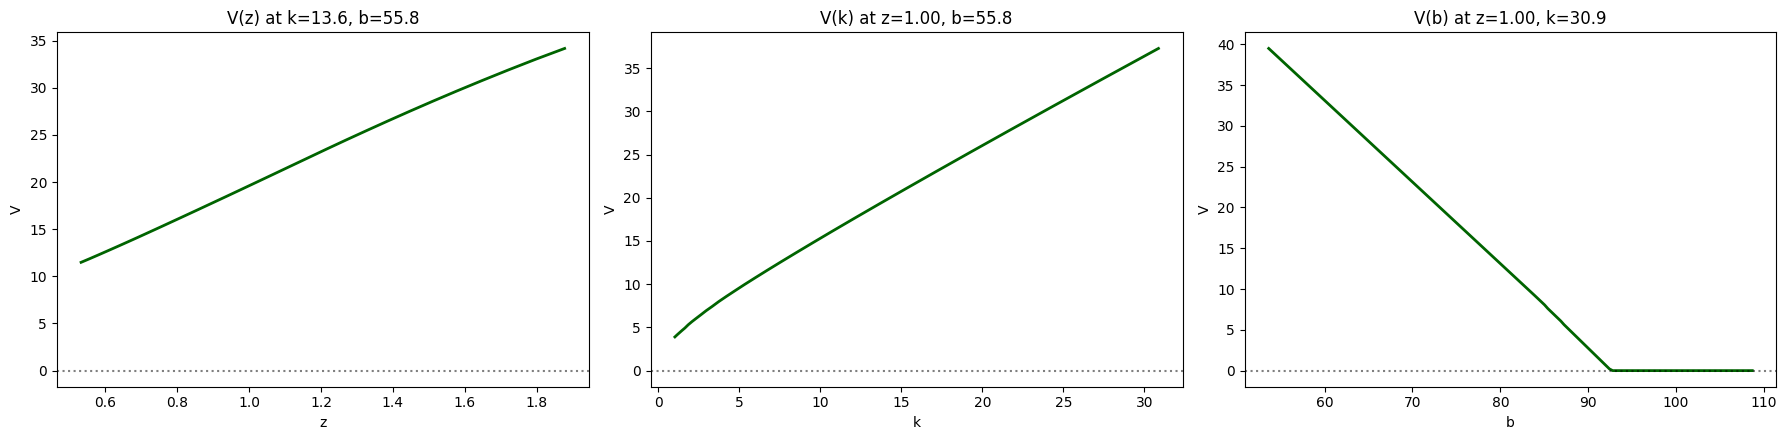

In [5]:
policy_line = dict(color="blue", linewidth=2.0)
value_line = dict(color="darkgreen", linewidth=2.0)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
kp_lim = (float(k_grid[0]), float(k_grid[-1]))
bp_lim = (float(b_grid[0]), float(b_grid[-1]))

# Column 1: vs z (median k, low b)
axes[0, 0].plot(z_grid, policy_z_plot[:, 0], **policy_line)
axes[0, 0].set(title=f"k'(z) at k={k_ref:.1f}, b={b_ref:.1f}", xlabel="z", ylabel="k'",
               xlim=(float(z_grid[0]), float(z_grid[-1])), ylim=kp_lim)
axes[1, 0].plot(z_grid, policy_z_plot[:, 1], **policy_line)
axes[1, 0].set(title=f"b'(z) at k={k_ref:.1f}, b={b_ref:.1f}", xlabel="z", ylabel="b'",
               xlim=(float(z_grid[0]), float(z_grid[-1])), ylim=bp_lim)

# Column 2: vs k (median k, low b)
axes[0, 1].plot(k_grid, policy_k_plot[:, 0], **policy_line)
axes[0, 1].set(title=f"k'(k) at z={z_bar:.2f}, b={b_ref:.1f}", xlabel="k", ylabel="k'",
               xlim=(float(k_grid[0]), float(k_grid[-1])), ylim=kp_lim)
axes[1, 1].plot(k_grid, policy_k_plot[:, 1], **policy_line)
axes[1, 1].set(title=f"b'(k) at z={z_bar:.2f}, b={b_ref:.1f}", xlabel="k", ylabel="b'",
               xlim=(float(k_grid[0]), float(k_grid[-1])), ylim=bp_lim)

# Column 3: vs b (high k — solvent across most b range)
axes[0, 2].plot(b_grid, policy_b_plot[:, 0], **policy_line)
axes[0, 2].set(title=f"k'(b) at z={z_bar:.2f}, k={k_bslice:.1f}", xlabel="b", ylabel="k'",
               xlim=(float(b_grid[0]), float(b_grid[-1])), ylim=kp_lim)
axes[1, 2].plot(b_grid, policy_b_plot[:, 1], **policy_line)
axes[1, 2].set(title=f"b'(b) at z={z_bar:.2f}, k={k_bslice:.1f}", xlabel="b", ylabel="b'",
               xlim=(float(b_grid[0]), float(b_grid[-1])), ylim=bp_lim)

plt.tight_layout()
save_figure(RUN, fig, "policy_slices")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, x, y, xlabel, title in [
    (axes[0], z_grid, value_z, "z", f"V(z) at k={k_ref:.1f}, b={b_ref:.1f}"),
    (axes[1], k_grid, value_k, "k", f"V(k) at z={z_bar:.2f}, b={b_ref:.1f}"),
    (axes[2], b_grid, value_b, "b", f"V(b) at z={z_bar:.2f}, k={k_bslice:.1f}"),
]:
    ax.plot(x, y, **value_line)
    ax.axhline(0.0, color="black", linestyle=":", alpha=0.5)
    ax.set(title=title, xlabel=xlabel, ylabel="V")

plt.tight_layout()
save_figure(RUN, fig, "value_slices")
plt.show()

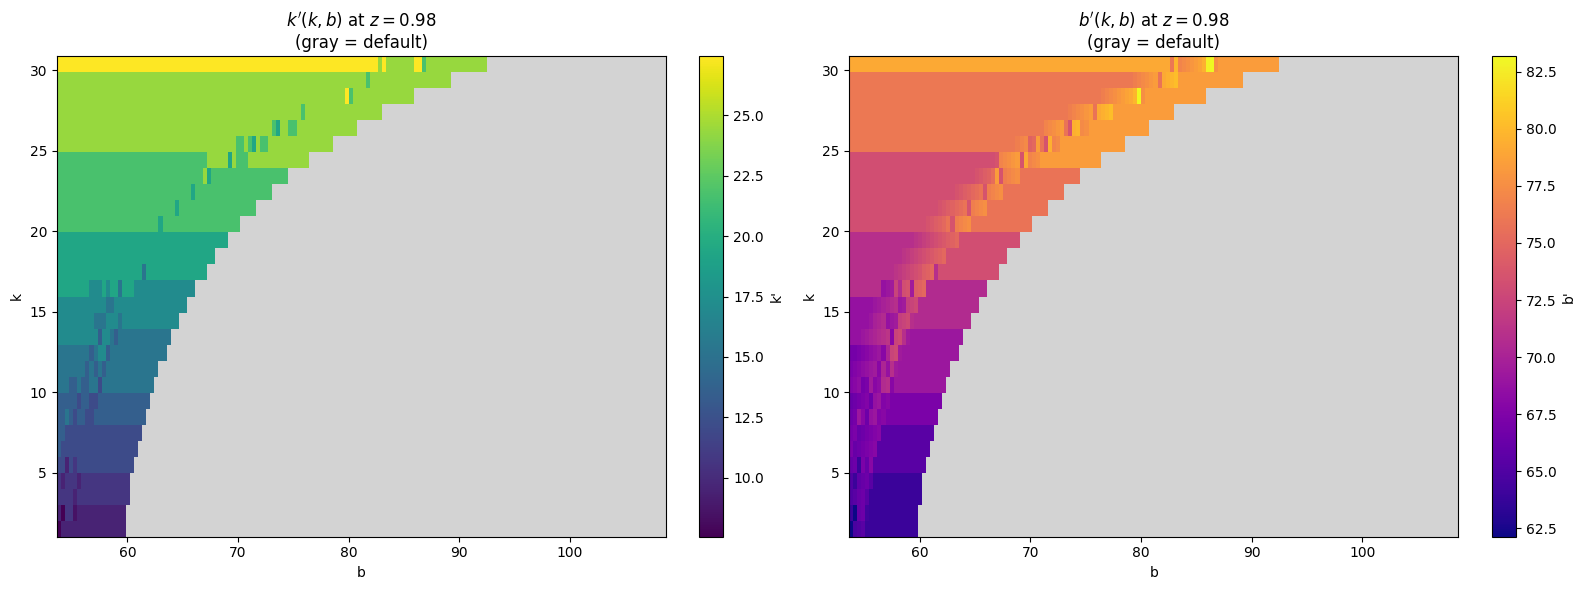

In [6]:
# 2D policy heatmaps: k'(k,b) and b'(k,b) at fixed z = z_bar
policy_kprime = policy_endo_4d[z_ref_idx, :, :, 0]  # (n_k, n_b)
policy_bprime = policy_endo_4d[z_ref_idx, :, :, 1]  # (n_k, n_b)
value_at_z = value_3d[z_ref_idx]                      # (n_k, n_b)

# Mask default states
policy_kprime_plot = np.where(value_at_z > VALUE_TOL, policy_kprime, np.nan)
policy_bprime_plot = np.where(value_at_z > VALUE_TOL, policy_bprime, np.nan)

cmap_k = plt.cm.viridis.copy()
cmap_k.set_bad(color="lightgray")
cmap_b = plt.cm.plasma.copy()
cmap_b.set_bad(color="lightgray")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
extent = [b_grid[0], b_grid[-1], k_grid[0], k_grid[-1]]

im0 = axes[0].imshow(
    policy_kprime_plot, origin="lower", aspect="auto", extent=extent, cmap=cmap_k,
)
axes[0].set_title(f"$k'(k, b)$ at $z = {z_ref:.2f}$\n(gray = default)")
axes[0].set_xlabel("b")
axes[0].set_ylabel("k")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="k'")

im1 = axes[1].imshow(
    policy_bprime_plot, origin="lower", aspect="auto", extent=extent, cmap=cmap_b,
)
axes[1].set_title(f"$b'(k, b)$ at $z = {z_ref:.2f}$\n(gray = default)")
axes[1].set_xlabel("b")
axes[1].set_ylabel("k")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="b'")

plt.tight_layout()
save_figure(RUN, fig, "policy_2d_heatmaps")
plt.show()

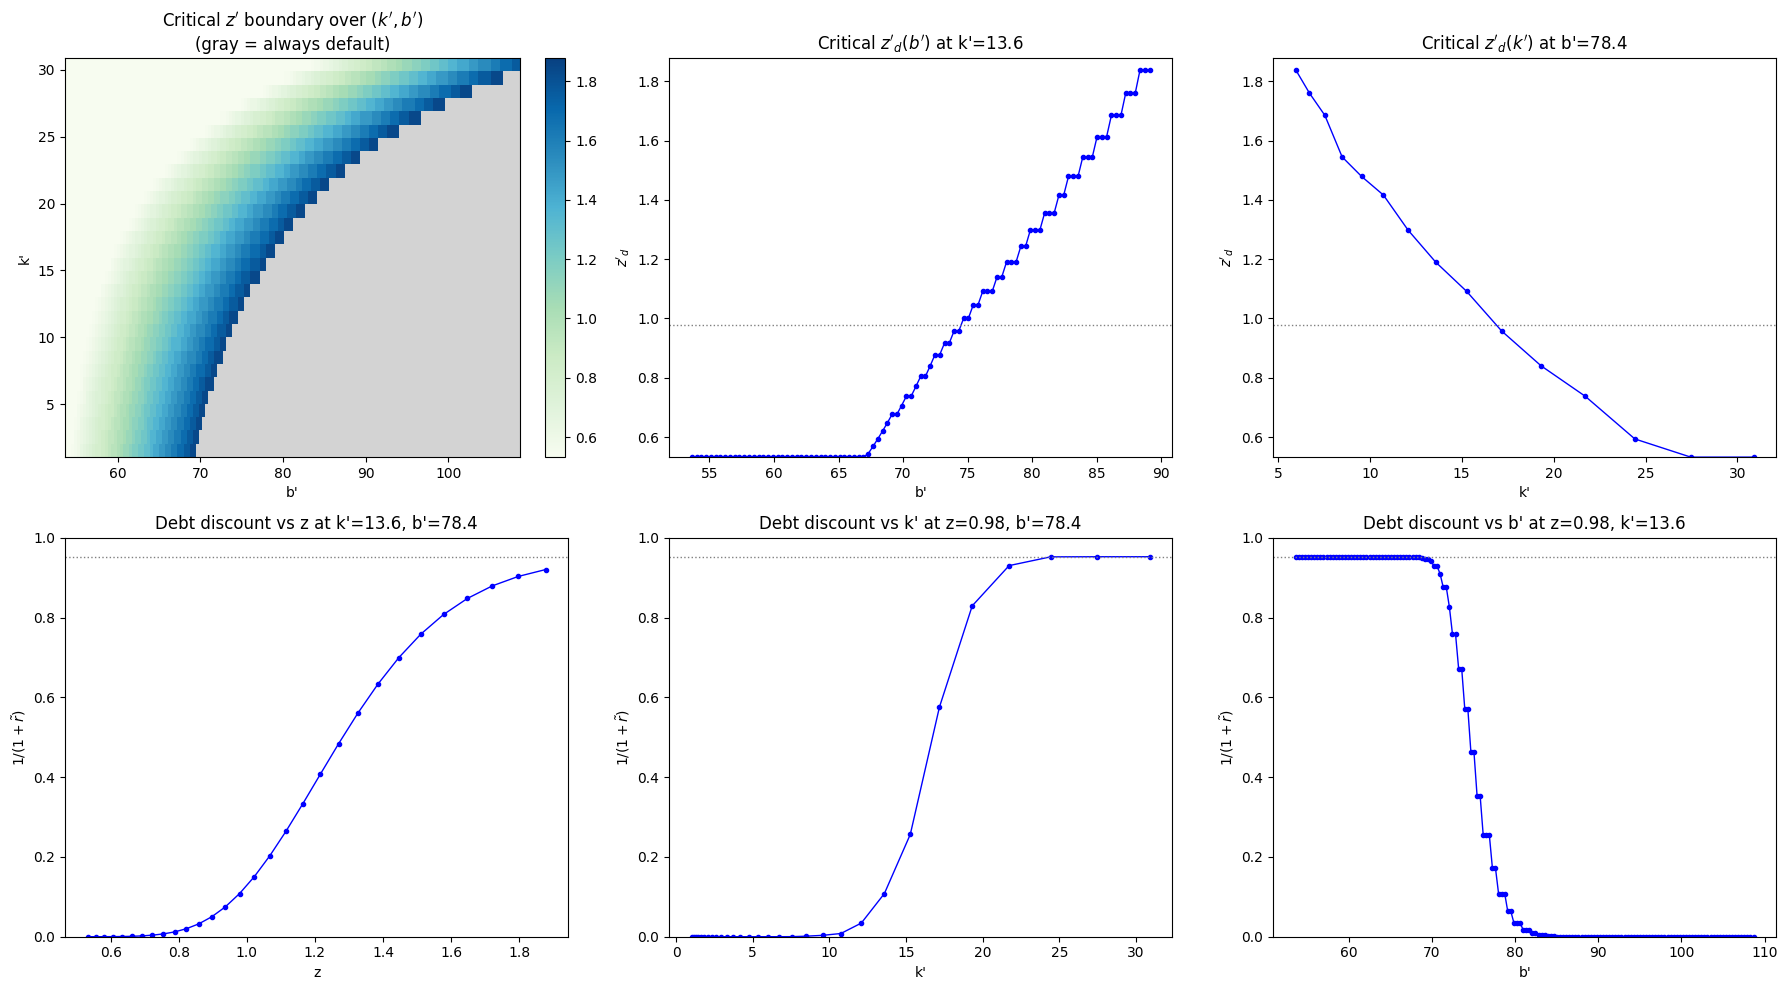

In [7]:
def _critical_z_boundary(value_grid, z_nodes):
    boundary = np.full(value_grid.shape[1:], np.nan, dtype=float)
    for ki in range(value_grid.shape[1]):
        for bi in range(value_grid.shape[2]):
            s = np.flatnonzero(value_grid[:, ki, bi] > VALUE_TOL)
            if s.size == 0:
                continue
            if s[0] == 0:
                boundary[ki, bi] = float(z_nodes[0])
            else:
                boundary[ki, bi] = 0.5 * (float(z_nodes[s[0]-1]) + float(z_nodes[s[0]]))
    return boundary

critical_z_grid = _critical_z_boundary(value_3d, z_grid)
debt_discount_grid = np.where(np.isfinite(r_tilde_grid), 1.0 / (1.0 + r_tilde_grid), 0.0)
discount_cap = 1.0 / (1.0 + env.econ.interest_rate)

# Pick diagnostic (k, b) near the default frontier for discount/boundary plots
cz_row = critical_z_grid[k_ref_idx, :]
interior = np.flatnonzero(np.isfinite(cz_row) & (cz_row > float(z_grid[0])) & (cz_row < float(z_grid[-1])))
b_diag_idx = int(interior[len(interior)//2]) if interior.size else n_b // 2
k_diag = float(k_grid[k_ref_idx])
b_diag = float(b_grid[b_diag_idx])

line_style = dict(color="blue", linewidth=1.0)
critical_cmap = plt.cm.GnBu.copy()
critical_cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im = axes[0, 0].imshow(
    critical_z_grid, origin="lower", aspect="auto",
    extent=[b_grid[0], b_grid[-1], k_grid[0], k_grid[-1]],
    cmap=critical_cmap, vmin=float(z_grid[0]), vmax=float(z_grid[-1]),
)
axes[0, 0].set(title="Critical $z'$ boundary over $(k', b')$\n(gray = always default)",
               xlabel="b'", ylabel="k'")
fig.colorbar(im, ax=axes[0, 0], fraction=0.046)

axes[0, 1].plot(b_grid, critical_z_grid[k_ref_idx, :], marker=".", **line_style)
axes[0, 1].axhline(z_ref, color="gray", linestyle=":", linewidth=1.0)
axes[0, 1].set(title=f"Critical $z'_d(b')$ at k'={k_diag:.1f}", xlabel="b'", ylabel="$z'_d$",
               ylim=(float(z_grid[0]), float(z_grid[-1])))

axes[0, 2].plot(k_grid, critical_z_grid[:, b_diag_idx], marker=".", **line_style)
axes[0, 2].axhline(z_ref, color="gray", linestyle=":", linewidth=1.0)
axes[0, 2].set(title=f"Critical $z'_d(k')$ at b'={b_diag:.1f}", xlabel="k'", ylabel="$z'_d$",
               ylim=(float(z_grid[0]), float(z_grid[-1])))

axes[1, 0].plot(z_grid, debt_discount_grid[:, k_ref_idx, b_diag_idx], marker=".", **line_style)
axes[1, 0].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 0].set(title=f"Debt discount vs z at k'={k_diag:.1f}, b'={b_diag:.1f}",
               xlabel="z", ylabel="$1 / (1 + \\tilde r)$", ylim=(0, 1))

axes[1, 1].plot(k_grid, debt_discount_grid[z_ref_idx, :, b_diag_idx], marker=".", **line_style)
axes[1, 1].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 1].set(title=f"Debt discount vs k' at z={z_ref:.2f}, b'={b_diag:.1f}",
               xlabel="k'", ylabel="$1 / (1 + \\tilde r)$", ylim=(0, 1))

axes[1, 2].plot(b_grid, debt_discount_grid[z_ref_idx, k_ref_idx, :], marker=".", **line_style)
axes[1, 2].axhline(discount_cap, color="gray", linestyle=":", linewidth=1.0)
axes[1, 2].set(title=f"Debt discount vs b' at z={z_ref:.2f}, k'={k_diag:.1f}",
               xlabel="b'", ylabel="$1 / (1 + \\tilde r)$", ylim=(0, 1))

plt.tight_layout()
save_figure(RUN, fig, "boundary_and_discount_slices")
plt.show()